# Model 2B, CatBoost Experiment 01: Pushback Schedule Margin

This append-only experiment applies CatBoost to the pushback-time representation selected by Logistic Regression 2B Experiment 02. It retains BL-A-27, signed `DepDelay`, and the model-side field `MINUTES_TO_SCHEDULED_ARRIVAL_AT_PUSHBACK = CRSElapsedTime - DepDelay`.

CatBoost receives the schedule margin as one numeric field because trees can learn nonlinear splits without a spline. Depth, learning rate, L2 leaf regularization, class weighting, and tree count are selected using five expanding 2019 folds. The selected model and operating threshold are frozen before one 2023 evaluation. No new feature dataset is created, and the 2024 dataset is not loaded.


In [1]:
AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "ArrDel15"

RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 4
MAX_ITERATIONS = 1000
EARLY_STOPPING_ROUNDS = 75

In [2]:
from itertools import product
from pathlib import Path
from time import perf_counter

import catboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"CatBoost version: {catboost.__version__}")

CatBoost version: 1.2.10


## Load and validate the shared arrival feature datasets

The experiment uses the same 2019 training rows and 2023 validation rows as the completed Model 2B experiments.


In [3]:
def find_project_root(start: Path, airport: str, years) -> Path:
    required = [
        Path("data/features") / f"{airport}_{year}_arrivals.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required feature datasets: {required}")


PROJECT_ROOT = find_project_root(
    Path.cwd().resolve(),
    AIRPORT,
    [TRAIN_YEAR, VALIDATION_YEAR],
)
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_arrivals.csv"
VALIDATION_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_arrivals.csv"

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)


def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    required = {"FlightDate", "Dest", TARGET}
    missing = sorted(required.difference(frame.columns))
    assert not missing, f"{partition} missing columns: {missing}"
    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="raise")
    assert frame["FlightDate"].dt.year.eq(year).all()
    assert frame["Dest"].eq(AIRPORT).all()
    assert frame[TARGET].notna().all()
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0})
    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
    }


source_summary = pd.DataFrame([
    validate_source_frame(train_df, TRAIN_YEAR, "training"),
    validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
]).set_index("partition")
source_summary

,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107354,21784,0.2029
external validation,2023,2023-01-01,2023-12-31,365,109947,27077,0.2463


## Use the selected Model 2B source allowlist and schedule margin

The model uses 28 saved source fields and one calculated field. `Reporting_Airline` and `Origin` remain native categorical fields.


In [4]:
MODEL_2A_CATEGORICAL_FEATURES = [
    "Reporting_Airline",
    "Origin",
]

MODEL_2A_NUMERIC_FEATURES = [
    "SCHED_DEP_TIME_SIN",
    "SCHED_DEP_TIME_COS",
    "SCHED_ARR_TIME_SIN",
    "SCHED_ARR_TIME_COS",
    "DAY_OF_WEEK_SIN",
    "DAY_OF_WEEK_COS",
    "DAY_OF_YEAR_SIN",
    "DAY_OF_YEAR_COS",
    "IS_WEEKEND",
    "CRSElapsedTime",
    "LOG_DISTANCE",
    "SCHEDULED_SPEED_PROXY",
    "ASPM_THREE_HOUR_SCHEDULED_DEPARTURES",
    "ASPM_THREE_HOUR_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC",
    "ASPM_NEXT_MINUS_CURRENT_TRAFFIC",
    "ASPM_MAX_HOURLY_TRAFFIC",
    "HourlyDryBulbTemperature",
    "TEMP_DEWPOINT_SPREAD",
    "LOG_PRECIPITATION",
    "HourlyVisibility",
    "WindX",
    "WindY",
    "ADVERSE_WEATHER",
    "NOAA_AGE_MINUTES",
]

CALCULATED_MARGIN = "MINUTES_TO_SCHEDULED_ARRIVAL_AT_PUSHBACK"
categorical_features = list(MODEL_2A_CATEGORICAL_FEATURES)
source_numeric_features = [*MODEL_2A_NUMERIC_FEATURES, "DepDelay"]
numeric_features = [*source_numeric_features, CALCULATED_MARGIN]
source_feature_columns = [*categorical_features, *source_numeric_features]
feature_columns = [*categorical_features, *numeric_features]
required_columns = [
    "FlightDate",
    "Dest",
    "CRSDepTime",
    TARGET,
    *source_feature_columns,
]

assert len(source_feature_columns) == len(set(source_feature_columns)) == 28
assert len(feature_columns) == len(set(feature_columns)) == 29
assert len(categorical_features) == 2 and len(numeric_features) == 27

for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing = sorted(set(required_columns).difference(frame.columns))
    assert not missing, f"{partition} missing required columns: {missing}"

forbidden_predictors = {
    TARGET,
    "DepTime",
    "DepDelayMinutes",
    "DepDel15",
    "DepartureDelayGroups",
    "ACTUAL_DEP_MINUTE_OF_DAY",
    "ACTUAL_DEP_TIME_SIN",
    "ACTUAL_DEP_TIME_COS",
    "DEPARTED_EARLY",
    "LOG_DEP_DELAY_MINUTES",
    "TaxiOut",
    "WheelsOff",
    "ACTUAL_TAKEOFF_MINUTE_OF_DAY",
    "ACTUAL_TAKEOFF_TIME_SIN",
    "ACTUAL_TAKEOFF_TIME_COS",
    "LOG_TAXI_OUT_MINUTES",
    "ArrTime",
    "ArrDelay",
    "ArrDelayMinutes",
    "ArrivalDelayGroups",
    "WheelsOn",
    "TaxiIn",
    "ActualElapsedTime",
    "AirTime",
    "Tail_Number",
}
assert not forbidden_predictors.intersection(source_feature_columns)

pd.Series({
    "saved source fields": len(source_feature_columns),
    "calculated model-side fields": 1,
    "CatBoost inputs": len(feature_columns),
    "native categorical fields": len(categorical_features),
    "numeric fields": len(numeric_features),
}, name="CatBoost 2B input design").to_frame()


,CatBoost 2B input design
saved source fields,28
calculated model-side fields,1
CatBoost inputs,29
native categorical fields,2
numeric fields,27


## Prepare the model frames and chronological folds

The pushback margin is calculated after row selection and before the model frames are split. Every learned CatBoost setting remains fold-local.


In [5]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)
    for column in categorical_features:
        frame[column] = frame[column].astype("string").fillna("MISSING").astype(str)
    for column in source_numeric_features:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame[CALCULATED_MARGIN] = frame["CRSElapsedTime"] - frame["DepDelay"]
    return frame


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)

X_train = train_model_df[feature_columns].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
X_validation = validation_model_df[feature_columns].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)

assert training_dates.max() < validation_dates.min()
assert X_train[CALCULATED_MARGIN].notna().all()
assert X_validation[CALCULATED_MARGIN].notna().all()

missing_summary = pd.DataFrame({
    "training_missing": X_train.isna().sum(),
    "validation_missing": X_validation.isna().sum(),
})
display(missing_summary[missing_summary.sum(axis=1).gt(0)])
pd.DataFrame({
    "training": X_train[CALCULATED_MARGIN].describe(),
    "external_validation": X_validation[CALCULATED_MARGIN].describe(),
})


,training_missing,validation_missing
ASPM_THREE_HOUR_SCHEDULED_DEPARTURES,14,10
ASPM_THREE_HOUR_SCHEDULED_ARRIVALS,14,10
ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC,1,0
ASPM_NEXT_MINUS_CURRENT_TRAFFIC,13,10
ASPM_MAX_HOURLY_TRAFFIC,14,10
HourlyDryBulbTemperature,6,6
TEMP_DEWPOINT_SPREAD,26,11
LOG_PRECIPITATION,12,19
HourlyVisibility,60,41
WindX,935,963


,training,external_validation
count,"107,354.0000","109,947.0000"
mean,196.4792,184.5017
std,112.3869,117.2643
min,"-1,348.0000","-2,255.0000"
25%,116.0000,112.0000
50%,176.0000,166.0000
75%,307.0000,283.0000
max,591.0000,618.0000


In [6]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized)))
    assert len(unique_days) >= n_splits + 1
    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits, rows = [], []

    for fold in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold])
        heldout_days = day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold,
            "train_rows": len(train_idx),
            "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })

    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates,
    y_train,
    N_TIME_SPLITS,
)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17776,18725,2019-03-02,2019-03-03,2019-05-02,0.2082,0.1834
2,36501,18153,2019-05-02,2019-05-03,2019-07-02,0.1955,0.2319
3,54654,17703,2019-07-02,2019-07-03,2019-09-01,0.2076,0.2646
4,72357,17650,2019-09-01,2019-09-02,2019-11-01,0.2215,0.1474
5,90007,17347,2019-11-01,2019-11-02,2019-12-31,0.2070,0.1818


## Training-only CatBoost search

The 16 candidates combine depths 4 and 6, learning rates 0.03 and 0.10, L2 leaf regularization 3 and 10, and no versus balanced class weighting. Fold-local early stopping selects tree counts; mean temporal average precision selects the configuration.


In [7]:
parameter_candidates = [
    {
        "depth": depth,
        "learning_rate": rate,
        "l2_leaf_reg": regularization,
        "class_weighting": class_weighting,
    }
    for depth, rate, regularization, class_weighting
    in product([4, 6], [0.03, 0.10], [3, 10], ["None", "Balanced"])
]


def make_catboost_model(parameters, iterations=MAX_ITERATIONS, use_best_model=True):
    return CatBoostClassifier(
        iterations=iterations,
        loss_function="Logloss",
        eval_metric="PRAUC:type=Classic",
        depth=parameters["depth"],
        learning_rate=parameters["learning_rate"],
        l2_leaf_reg=parameters["l2_leaf_reg"],
        auto_class_weights=(
            None if parameters["class_weighting"] == "None"
            else parameters["class_weighting"]
        ),
        random_seed=RANDOM_STATE,
        thread_count=N_JOBS,
        allow_writing_files=False,
        verbose=False,
        use_best_model=use_best_model,
    )


search_start = perf_counter()
search_rows = []

for candidate_number, parameters in enumerate(parameter_candidates, start=1):
    for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
        model = make_catboost_model(parameters)
        model.fit(
            X_train.iloc[train_idx],
            y_train.iloc[train_idx],
            cat_features=categorical_features,
            eval_set=(X_train.iloc[heldout_idx], y_train.iloc[heldout_idx]),
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            verbose=False,
        )
        probabilities = model.predict_proba(X_train.iloc[heldout_idx])[:, 1]
        search_rows.append({
            "candidate": candidate_number,
            "fold": fold_number,
            **parameters,
            "best_iteration": model.get_best_iteration() + 1,
            "average_precision": average_precision_score(
                y_train.iloc[heldout_idx], probabilities
            ),
            "roc_auc": roc_auc_score(y_train.iloc[heldout_idx], probabilities),
            "brier_score": brier_score_loss(y_train.iloc[heldout_idx], probabilities),
        })
    print(f"Completed candidate {candidate_number}/{len(parameter_candidates)}: {parameters}")

search_seconds = perf_counter() - search_start
fold_search_results = pd.DataFrame(search_rows)
candidate_results = (
    fold_search_results
    .groupby(
        ["candidate", "depth", "learning_rate", "l2_leaf_reg", "class_weighting"],
        as_index=False,
    )
    .agg(
        mean_average_precision=("average_precision", "mean"),
        std_average_precision=("average_precision", "std"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_brier_score=("brier_score", "mean"),
        median_best_iteration=("best_iteration", "median"),
        min_best_iteration=("best_iteration", "min"),
        max_best_iteration=("best_iteration", "max"),
    )
    .sort_values(["mean_average_precision", "mean_roc_auc"], ascending=False)
)

best_candidate = candidate_results.iloc[0]
selected_parameters = {
    "depth": int(best_candidate["depth"]),
    "learning_rate": float(best_candidate["learning_rate"]),
    "l2_leaf_reg": float(best_candidate["l2_leaf_reg"]),
    "class_weighting": str(best_candidate["class_weighting"]),
}
selected_iterations = max(1, int(best_candidate["median_best_iteration"]))

print(f"Temporal search completed in {search_seconds:,.1f} seconds")
print(f"Best mean temporal-validation AP: {best_candidate['mean_average_precision']:.4f}")
print(f"Selected parameters: {selected_parameters}")
print(f"Selected iteration count: {selected_iterations}")
candidate_results

Completed candidate 1/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'class_weighting': 'None'}


Completed candidate 2/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'class_weighting': 'Balanced'}


Completed candidate 3/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'class_weighting': 'None'}


Completed candidate 4/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'class_weighting': 'Balanced'}


Completed candidate 5/16: {'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'class_weighting': 'None'}


...

Completed candidate 13/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'class_weighting': 'None'}


Completed candidate 14/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'class_weighting': 'Balanced'}


Completed candidate 15/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 10, 'class_weighting': 'None'}


Completed candidate 16/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 10, 'class_weighting': 'Balanced'}
Temporal search completed in 327.2 seconds
Best mean temporal-validation AP: 0.8714
Selected parameters: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 10.0, 'class_weighting': 'Balanced'}
Selected iteration count: 62


,candidate,depth,learning_rate,l2_leaf_reg,class_weighting,mean_average_precision,std_average_precision,mean_roc_auc,mean_brier_score,median_best_iteration,min_best_iteration,max_best_iteration
15,16,6,0.1000,10,Balanced,0.8714,0.0267,0.9286,0.0696,62.0000,29,156
8,9,6,0.0300,3,None,0.8713,0.0261,0.9281,0.0593,225.0000,33,587
10,11,6,0.0300,10,None,0.8713,0.0269,0.9283,0.0585,188.0000,45,453
14,15,6,0.1000,10,None,0.8711,0.0270,0.9283,0.0585,57.0000,15,187
13,14,6,0.1000,3,Balanced,0.8708,0.0266,0.9280,0.0716,41.0000,19,183
12,13,6,0.1000,3,None,0.8707,0.0266,0.9276,0.0585,43.0000,16,204
0,1,4,0.0300,3,None,0.8707,0.0264,0.9270,0.0582,265.0000,132,644
11,12,6,0.0300,10,Balanced,0.8706,0.0266,0.9279,0.0719,157.0000,61,488
9,10,6,0.0300,3,Balanced,0.8706,0.0277,0.9274,0.0721,145.0000,91,398
6,7,4,0.1000,10,None,0.8706,0.0261,0.9276,0.0585,115.0000,42,419


## Select the operating threshold using 2019 only

The selected configuration is refitted within each chronological fold. The F1 threshold is selected from aligned held-out 2019 probabilities.


In [8]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


oof_probabilities = np.full(len(y_train), np.nan)
for train_idx, heldout_idx in temporal_splits:
    fold_model = make_catboost_model(
        selected_parameters,
        iterations=selected_iterations,
        use_best_model=False,
    )
    fold_model.fit(
        X_train.iloc[train_idx],
        y_train.iloc[train_idx],
        cat_features=categorical_features,
        verbose=False,
    )
    oof_probabilities[heldout_idx] = fold_model.predict_proba(
        X_train.iloc[heldout_idx]
    )[:, 1]

oof_mask = np.isfinite(oof_probabilities)
oof_y = y_train.to_numpy()[oof_mask]
oof_p = oof_probabilities[oof_mask]

threshold_results = pd.DataFrame([
    evaluate_probabilities(oof_y, oof_p, threshold)
    for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2)
])
selected_threshold = float(
    threshold_results.sort_values(
        ["f1", "balanced_accuracy", "precision"],
        ascending=False,
    ).iloc[0]["threshold"]
)

print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"],
    ascending=False,
).head(10)

Threshold-selection rows: 89,578
Training-only selected threshold: 0.50


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
45,0.5000,0.9165,0.8654,0.8013,0.7797,0.7904,0.7383,0.9266,0.8733,0.0702
44,0.4900,0.9154,0.8658,0.7953,0.7825,0.7889,0.7361,0.9266,0.8733,0.0702
43,0.4800,0.9144,0.8663,0.7896,0.7854,0.7875,0.7340,0.9266,0.8733,0.0702
42,0.4700,0.9134,0.8665,0.7843,0.7878,0.7861,0.7318,0.9266,0.8733,0.0702
41,0.4600,0.9124,0.8668,0.7789,0.7904,0.7846,0.7297,0.9266,0.8733,0.0702
40,0.4500,0.9112,0.8672,0.7726,0.7934,0.7829,0.7271,0.9266,0.8733,0.0702
39,0.4400,0.9097,0.8673,0.7655,0.7964,0.7806,0.7240,0.9266,0.8733,0.0702
38,0.4300,0.9081,0.8671,0.7591,0.7982,0.7782,0.7207,0.9266,0.8733,0.0702
37,0.4200,0.9065,0.8669,0.7520,0.8006,0.7756,0.7171,0.9266,0.8733,0.0702
36,0.4100,0.9050,0.8672,0.7455,0.8038,0.7735,0.7143,0.9266,0.8733,0.0702


## Refit on all 2019 rows and evaluate 2023

Only the CatBoost design selected from 2019 is evaluated on 2023. Logistic Regression 2B-02 is a fixed documented comparison.


In [9]:
final_fit_start = perf_counter()
best_catboost_model = make_catboost_model(
    selected_parameters,
    iterations=selected_iterations,
    use_best_model=False,
)
best_catboost_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    verbose=False,
)
final_fit_seconds = perf_counter() - final_fit_start
validation_probabilities = best_catboost_model.predict_proba(X_validation)[:, 1]

evaluation_results = pd.DataFrame([
    {
        "model": "Logistic Regression 2B-02 (documented)",
        "threshold": 0.39,
        "accuracy": 0.9058,
        "balanced_accuracy": 0.8412,
        "precision": 0.8812,
        "recall": 0.7138,
        "f1": 0.7887,
        "mcc": 0.7357,
        "roc_auc": 0.9150,
        "average_precision": 0.8704,
        "brier_score": 0.0748,
    },
    {
        "model": "CatBoost 2B-01 (default)",
        **evaluate_probabilities(y_validation, validation_probabilities, 0.50),
    },
    {
        "model": "CatBoost 2B-01 (training-selected)",
        **evaluate_probabilities(
            y_validation,
            validation_probabilities,
            selected_threshold,
        ),
    },
]).set_index("model")

print(
    f"Final all-2019 fit: {final_fit_seconds:,.1f} seconds; "
    f"trees: {best_catboost_model.tree_count_:,}"
)
evaluation_results


Final all-2019 fit: 1.3 seconds; trees: 62


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Logistic Regression 2B-02 (documented),0.3900,0.9058,0.8412,0.8812,0.7138,0.7887,0.7357,0.9150,0.8704,0.0748
CatBoost 2B-01 (default),0.5000,0.8948,0.8519,0.7978,0.7674,0.7823,0.7132,0.9178,0.8715,0.0869
CatBoost 2B-01 (training-selected),0.5000,0.8948,0.8519,0.7978,0.7674,0.7823,0.7132,0.9178,0.8715,0.0869


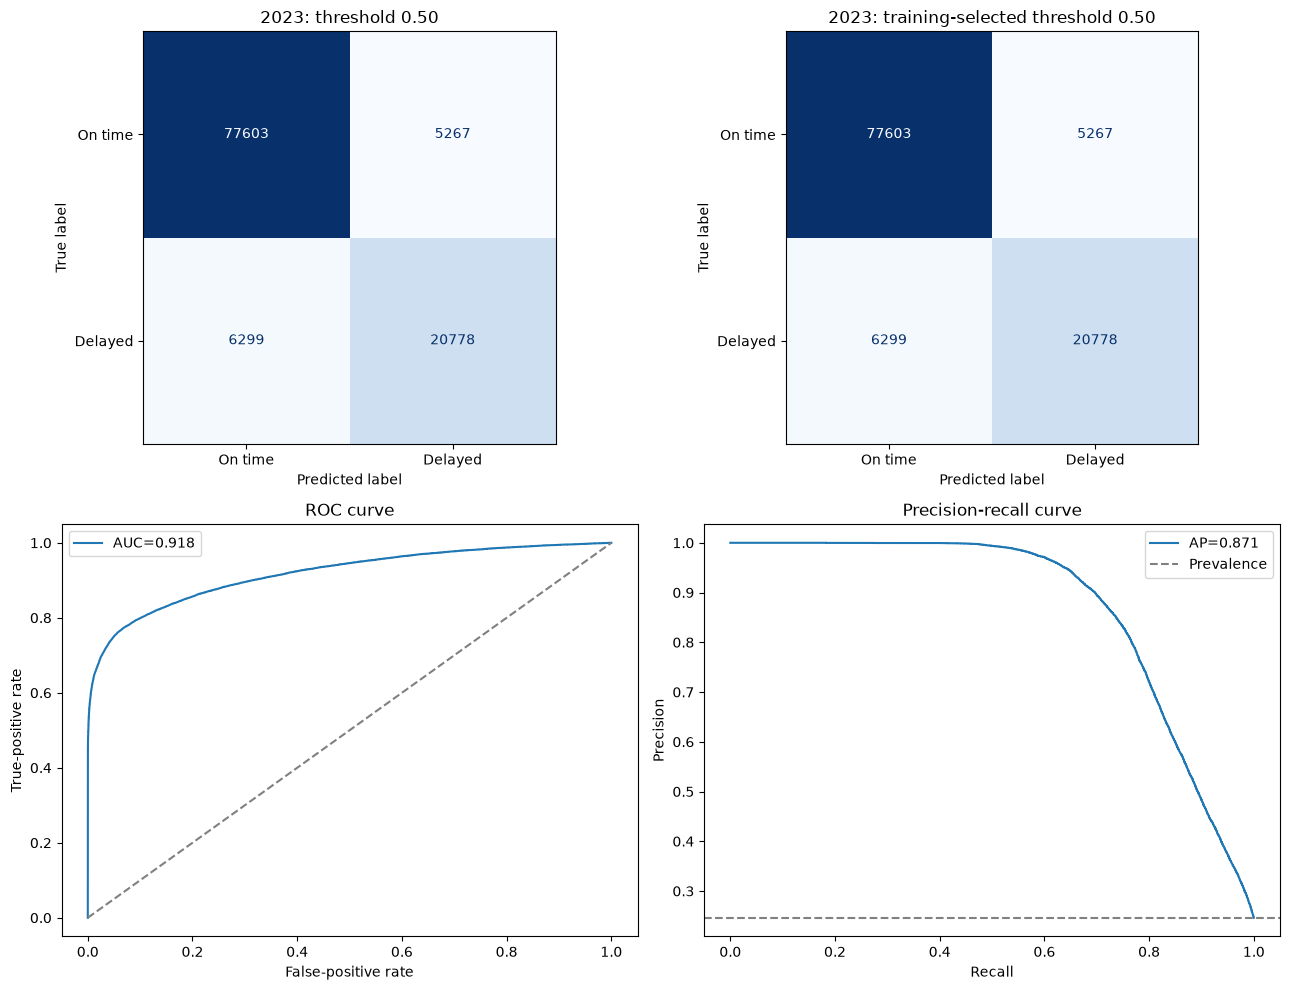

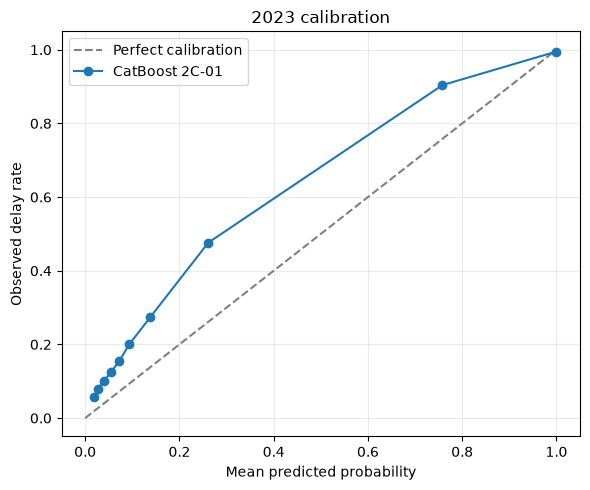

In [10]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_validation, validation_probabilities
)
curve_precision, curve_recall, _ = precision_recall_curve(
    y_validation, validation_probabilities
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    default_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("2023: threshold 0.50")
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"2023: training-selected threshold {selected_threshold:.2f}")
axes[1, 0].plot(
    false_positive_rate,
    true_positive_rate,
    label=f"AUC={roc_auc_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set(
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    title="ROC curve",
)
axes[1, 0].legend()
axes[1, 1].plot(
    curve_recall,
    curve_precision,
    label=f"AP={average_precision_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 1].axhline(
    y_validation.mean(),
    linestyle="--",
    color="gray",
    label="Prevalence",
)
axes[1, 1].set(
    xlabel="Recall",
    ylabel="Precision",
    title="Precision-recall curve",
)
axes[1, 1].legend()
fig.tight_layout()
plt.show()

predicted, observed = calibration_curve(
    y_validation,
    validation_probabilities,
    n_bins=10,
    strategy="quantile",
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(predicted, observed, marker="o", label="CatBoost 2C-01")
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed delay rate",
    title="2023 calibration",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Inspect feature importance and publishable values

CatBoost importance describes how the fitted model uses the available predictors. It does not establish that a field caused a delay.


In [11]:
feature_importance = (
    pd.DataFrame({
        "feature": feature_columns,
        "importance": best_catboost_model.get_feature_importance(),
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(feature_importance)

default = evaluation_results.loc["CatBoost 2B-01 (default)"]
selected = evaluation_results.loc["CatBoost 2B-01 (training-selected)"]
publishable_summary = pd.Series({
    "CatBoost version": catboost.__version__,
    "saved source fields": len(source_feature_columns),
    "calculated model-side fields": 1,
    "CatBoost inputs": len(feature_columns),
    "native categorical fields": len(categorical_features),
    "numeric fields": len(numeric_features),
    "selected depth": selected_parameters["depth"],
    "selected learning rate": selected_parameters["learning_rate"],
    "selected L2 leaf regularization": selected_parameters["l2_leaf_reg"],
    "selected class weighting": selected_parameters["class_weighting"],
    "selected trees": selected_iterations,
    "training CV AP": best_candidate["mean_average_precision"],
    "validation prevalence": y_validation.mean(),
    "validation AP": default["average_precision"],
    "validation ROC AUC": default["roc_auc"],
    "validation Brier": default["brier_score"],
    "selected threshold": selected_threshold,
    "selected-threshold accuracy": selected["accuracy"],
    "selected-threshold balanced accuracy": selected["balanced_accuracy"],
    "selected-threshold precision": selected["precision"],
    "selected-threshold recall": selected["recall"],
    "selected-threshold F1": selected["f1"],
    "selected-threshold MCC": selected["mcc"],
    "search seconds": search_seconds,
    "final fit seconds": final_fit_seconds,
}, name="CatBoost 2B Experiment 01 Appendix F values")
publishable_summary.to_frame()


,feature,importance
0,DepDelay,68.1435
1,DAY_OF_YEAR_COS,5.7049
2,DAY_OF_YEAR_SIN,3.8600
3,SCHED_ARR_TIME_SIN,2.6092
4,MINUTES_TO_SCHEDULED_ARRIVAL_AT_PUSHBACK,1.9105
5,SCHED_ARR_TIME_COS,1.8864
6,Reporting_Airline,1.8767
7,SCHED_DEP_TIME_COS,1.7419
8,CRSElapsedTime,1.6750
9,DAY_OF_WEEK_COS,1.6392


,CatBoost 2B Experiment 01 Appendix F values
CatBoost version,1.2.10
saved source fields,28
calculated model-side fields,1
CatBoost inputs,29
native categorical fields,2
numeric fields,27
selected depth,6
selected learning rate,0.1000
selected L2 leaf regularization,10.0000
selected class weighting,Balanced


## Interpretation checklist

1. Does CatBoost improve 2019 temporal average precision over Logistic Regression 2B-02?
2. Does any training gain persist in 2023 AP, ROC AUC, Brier score, F1, or MCC?
3. How strongly does the model use `DepDelay` and `MINUTES_TO_SCHEDULED_ARRIVAL_AT_PUSHBACK`?
4. Is the gain large enough to justify the more complex classifier?
5. Keep the existing feature dataset unchanged and keep 2024 untouched.
